In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../..')
from common.style import PRIMARY, PRIMARY_DARK, ACCENT, ACCENT_LIGHT, AXIS_COLOR, GRID_COLOR

da = pd.read_excel('../../utaut2_dataset/utaut2_subsample.xlsx')

construct_names = {
    'PU': 'Воспринимаемая полезность',
    'PEOU': 'Лёгкость использования',
    'SI': 'Социальное влияние',
    'FC': 'Поддерживающие условия',
    'HM': 'Гедоническая мотивация',
    'PV': 'Ценность цены',
    'HAB': 'Привычка',
    'BI': 'Поведенческое намерение'
}

constructs = ['PU', 'PEOU', 'SI', 'FC', 'HM', 'PV', 'HAB', 'BI']
predictors = ['PU', 'PEOU', 'SI', 'FC', 'HM', 'PV', 'HAB']

# Пункты конструктов (нужны для Cronbach alpha)
df_full = pd.read_excel('../../utaut2_dataset/new_result.xlsx')
cols = df_full.columns.tolist()
construct_items = {
    'PU':   cols[13:16],
    'PEOU': cols[16:19],
    'SI':   cols[19:22],
    'FC':   cols[22:25],
    'HM':   cols[25:28],
    'PV':   cols[28:31],
    'HAB':  cols[31:34],
    'BI':   cols[34:37],
}

print(f'Аналитическая подвыборка UTAUT2: {len(da)}')

Аналитическая подвыборка UTAUT2: 164


In [2]:
predictors = ['PU', 'PEOU', 'SI', 'FC', 'HM', 'PV', 'HAB']

corr_rows = []
for c in predictors:
    rho, p_value = stats.spearmanr(da[c], da['BI'])
    
    corr_rows.append({
        'Код': c,
        'Конструкт': construct_names[c],
        'ρ': round(rho, 3),
        'R²': round(rho**2, 3),
        'p-value': f'{p_value:.2e}' if p_value < 0.001 else f'{p_value:.4f}',
        'Значимость': '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'н.з.'
    })

corr_df = pd.DataFrame(corr_rows).sort_values('ρ', ascending=False).reset_index(drop=True)
corr_df

,Код,Конструкт,ρ,R²,p-value,Значимость
0,PU,Воспринимаемая полезность,0.584,0.341,2.17e-16,***
1,HAB,Привычка,0.434,0.188,6.51e-09,***
2,HM,Гедоническая мотивация,0.306,0.094,6.61e-05,***
3,SI,Социальное влияние,0.297,0.088,1.10e-04,***
4,PEOU,Лёгкость использования,0.296,0.088,1.19e-04,***
5,PV,Ценность цены,0.194,0.038,0.0130,*
6,FC,Поддерживающие условия,0.092,0.008,0.2430,н.з.


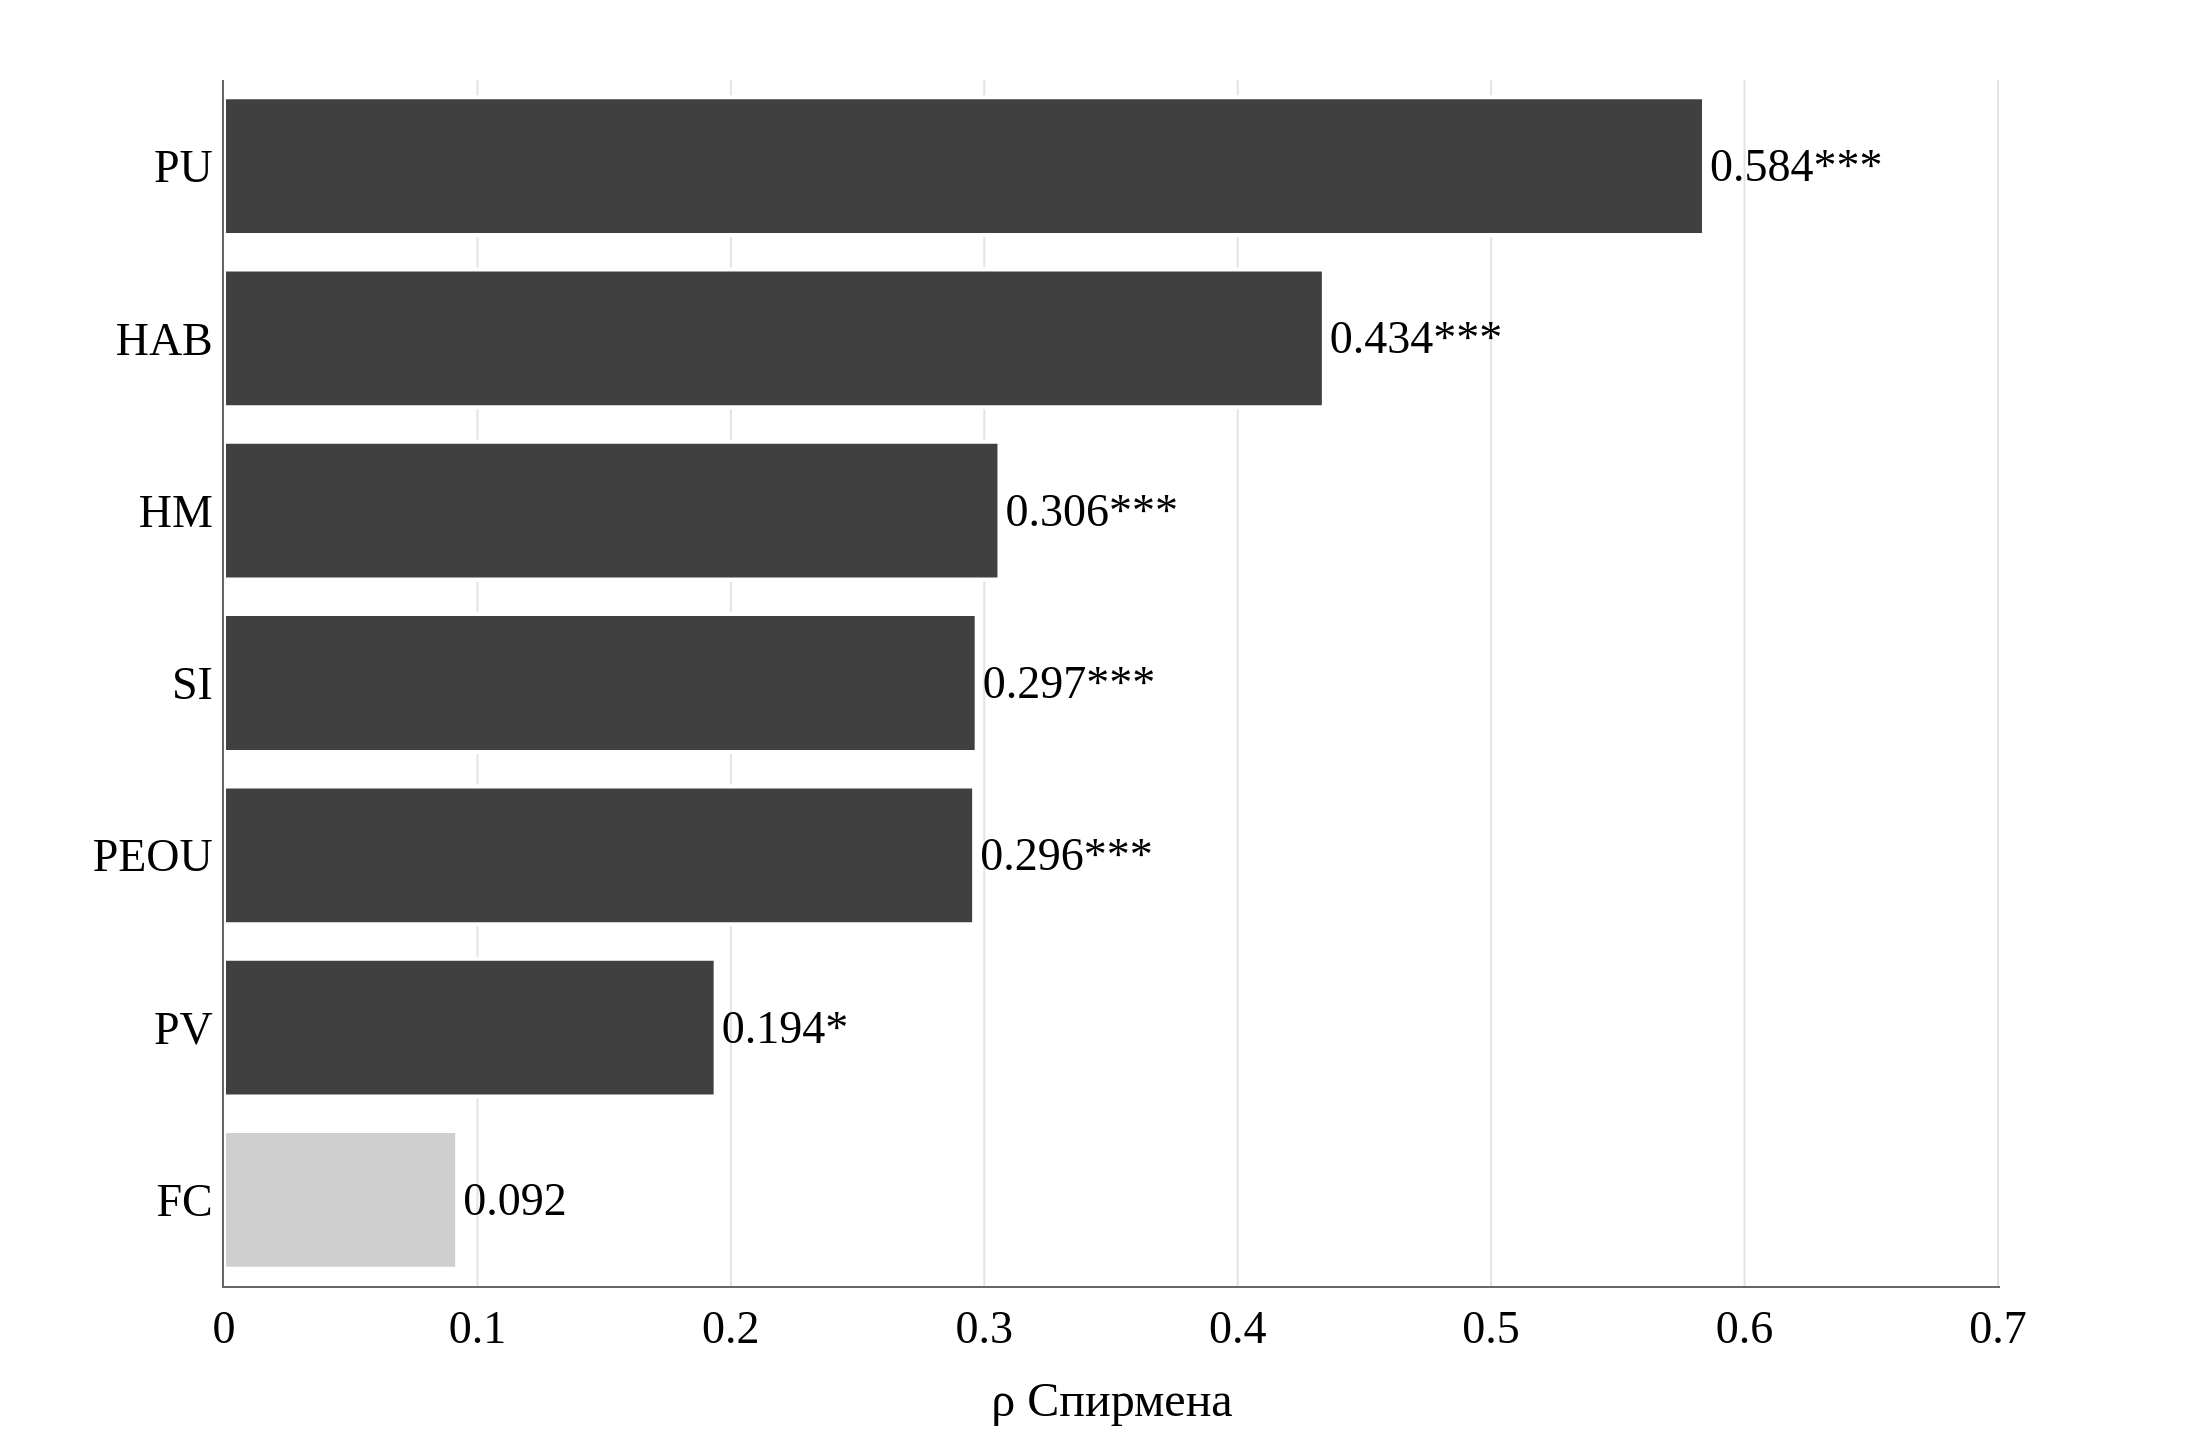

In [3]:
cs = corr_df.sort_values('ρ', ascending=True).copy()
colors = [PRIMARY if s != 'н.з.' else ACCENT_LIGHT for s in cs['Значимость']]

fig = go.Figure(data=[go.Bar(
    y=cs['Код'],
    x=cs['ρ'],
    orientation='h',
    text=[
        f'{rho:.3f}{sig}' if sig != 'н.з.' else f'{rho:.3f}'
        for rho, sig in zip(cs['ρ'], cs['Значимость'])
    ],
    textposition='outside',
    cliponaxis=False,
    textfont=dict(size=23, color='#000000', family='Times New Roman'),
    marker=dict(color=colors, line=dict(color='white', width=2)),
    hovertemplate='<b>%{y}</b><br>ρ = %{x:.3f}<extra></extra>'
)])

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(family='Times New Roman', size=23, color='#000000'),
    xaxis=dict(
        title=dict(text='ρ Спирмена', font=dict(size=24)),
        tickfont=dict(size=23),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[0, cs['ρ'].max() * 1.2]
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=23),
        showgrid=False,
        linecolor=AXIS_COLOR,
        linewidth=1
    ),
    margin=dict(l=90, r=100, t=40, b=70),
    width=1100,
    height=720
)

fig.show()


In [4]:
print('Связи конструктов с поведенческим намерением (BI):\n')

for _, row in corr_df.iterrows():
    print(f"{row['Код']}: ρ = {row['ρ']:.3f}, p = {row['p-value']} ({row['Значимость']})")

print('\nНаиболее сильные связи наблюдаются для PU и HAB.')
if (corr_df['Значимость'] == 'н.з.').any():
    nonsig = ', '.join(corr_df.loc[corr_df['Значимость'] == 'н.з.', 'Код'])
    print(f'Незначимая связь: {nonsig}.')

Связи конструктов с поведенческим намерением (BI):

PU: ρ = 0.584, p = 2.17e-16 (***)
HAB: ρ = 0.434, p = 6.51e-09 (***)
HM: ρ = 0.306, p = 6.61e-05 (***)
SI: ρ = 0.297, p = 1.10e-04 (***)
PEOU: ρ = 0.296, p = 1.19e-04 (***)
PV: ρ = 0.194, p = 0.0130 (*)
FC: ρ = 0.092, p = 0.2430 (н.з.)

Наиболее сильные связи наблюдаются для PU и HAB.
Незначимая связь: FC.
